# Speech Emotion Recognition — Training & Evaluation

Trains an emotion classifier on the preprocessed RAVDESS data in `Zenodo_processed/`.

**Pipeline:** load `.npy` features → pool over time → speaker-independent split (gender-balanced) → train MLP + SVM → evaluate on held-out actors → leave-one-actor-group-out CV → save best model → predict on a random sample.

In [1]:
import os
import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

RNG = 42
random.seed(RNG)
np.random.seed(RNG)

## 1. Configuration

RAVDESS filename format: `MM-VC-EE-II-SS-RR-AA.npy`
- `EE` (3rd field) → emotion code
- `AA` (7th field) → actor id (01–24, odd = male, even = female)

In [2]:
DATA_DIR = Path("Zenodo_processed")
MODEL_PATH = Path("emotion_model.pkl")

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

# Held-out test actors: 2 male (odd) + 2 female (even), gender-balanced.
TEST_ACTORS = {21, 22, 23, 24}
# Validation actors: 1 male + 1 female.
VAL_ACTORS = {19, 20}
# Everything else (1–18) is training.

assert DATA_DIR.exists(), f"Dataset directory not found: {DATA_DIR.resolve()}"

## 2. Index the dataset

Walk every `Actor_*` folder, parse the filename, and build a list of `(path, emotion, actor_id)` tuples.

In [3]:
FNAME_RE = re.compile(r"^(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})\.npy$")

records = []
for actor_dir in sorted(DATA_DIR.glob("Actor_*")):
    actor_id = int(actor_dir.name.split("_")[1])
    for fpath in sorted(actor_dir.glob("*.npy")):
        m = FNAME_RE.match(fpath.name)
        if not m:
            continue
        emotion_code = m.group(3)
        emotion = EMOTION_MAP[emotion_code]
        records.append((fpath, emotion, actor_id))

print(f"Total samples: {len(records)}")
print(f"Actors found:  {sorted({r[2] for r in records})}")
print("Per-emotion counts:")
for emo, count in sorted(Counter(r[1] for r in records).items()):
    print(f"  {emo:10s} {count}")

Total samples: 1440
Actors found:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Per-emotion counts:
  angry      192
  calm       192
  disgust    192
  fearful    192
  happy      192
  neutral    96
  sad        192
  surprised  192


## 3. Inspect one sample

We don't know the exact shape of the preprocessed features — the folder name says `Zenodo_processed`, so they could be mel-spectrograms, MFCC matrices, or something else. Print the shape so we know what we're working with.

In [4]:
sample_path, sample_emo, sample_actor = records[0]
sample = np.load(sample_path)
print(f"File:    {sample_path}")
print(f"Emotion: {sample_emo}")
print(f"Actor:   {sample_actor}")
print(f"Shape:   {sample.shape}")
print(f"Dtype:   {sample.dtype}")
print(f"Min/Max: {sample.min():.4f} / {sample.max():.4f}")
print(f"Mean/Std: {sample.mean():.4f} / {sample.std():.4f}")

File:    Zenodo_processed/Actor_01/03-01-01-01-01-01-01.npy
Emotion: neutral
Actor:   1
Shape:   (328, 400)
Dtype:   float64
Min/Max: -0.9213 / 0.9805
Mean/Std: -0.0002 / 0.0613


## 4. Reconstruct audio + extract features

The `.npy` files turned out to contain **raw audio samples reshaped into 2D matrices** (values in [-1, 1], near-zero mean — the signature of a normalized waveform). Mean+std pooling over the raw waveform throws away all temporal/spectral structure, which is why the first run got ~16% accuracy.

Real fix:
1. Flatten each `(N, 400)` matrix back to a 1D audio waveform.
2. Use **librosa** to extract proper acoustic features: MFCC + ΔMFCC, chroma, log-mel spectrogram, spectral contrast.
3. Mean+std-pool each of those over the time axis to get a fixed-size feature vector.

The cell below also plays back one clip so you can confirm the sample rate is right (RAVDESS clips should sound like clear English speech).

In [5]:
import librosa
from IPython.display import Audio, display

# Flatten the (N, 400) matrix back to a 1D audio waveform.
sample_1d = np.asarray(sample, dtype=np.float32).flatten()
print(f"Total samples: {len(sample_1d)}")
print("Possible durations:")
for sr in (16000, 22050, 44100, 48000):
    print(f"  at sr={sr}: {len(sample_1d) / sr:.2f}s")
print(f"\nValue range: [{sample_1d.min():.3f}, {sample_1d.max():.3f}]")

# RAVDESS clips are 3–5s including silence. Pick whichever rate above gives
# a duration in that range. 22050 is the most common choice for SER work.
# If the playback below sounds chipmunked or slowed-down, change this and re-run.
SAMPLE_RATE = 22050

print(f"\nUsing SAMPLE_RATE = {SAMPLE_RATE}")
print("→ Play below. Should sound like clear English speech ('Kids are talking by the door' / 'Dogs are sitting by the door').")
display(Audio(sample_1d, rate=SAMPLE_RATE))


def extract_features(arr: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """Flatten the preprocessed 2D array back to 1D audio and extract librosa features.

    Returns a fixed-size vector: mean + std (over time) of MFCC, ΔMFCC, chroma,
    log-mel spectrogram, and spectral contrast.
    """
    audio = np.asarray(arr, dtype=np.float32).flatten()
    # Trim leading/trailing silence; common preprocessing for RAVDESS.
    audio, _ = librosa.effects.trim(audio, top_db=25)
    if len(audio) < sr // 4:  # safeguard: must be at least 0.25s
        audio = np.asarray(arr, dtype=np.float32).flatten()

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64))
    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)

    parts = []
    for f in (mfcc, mfcc_delta, chroma, mel_db, contrast):
        parts.append(f.mean(axis=1))
        parts.append(f.std(axis=1))
    return np.concatenate(parts).astype(np.float32)


demo_vec = extract_features(sample)
print(f"\nFeature vector shape: {demo_vec.shape}")

Total samples: 131200
Possible durations:
  at sr=16000: 8.20s
  at sr=22050: 5.95s
  at sr=44100: 2.98s
  at sr=48000: 2.73s

Value range: [-0.921, 0.980]

Using SAMPLE_RATE = 22050
→ Play below. Should sound like clear English speech ('Kids are talking by the door' / 'Dogs are sitting by the door').



Feature vector shape: (326,)


## 5. Load all features into memory

In [6]:
X_list, y_list, actor_list = [], [], []
for i, (fpath, emotion, actor_id) in enumerate(records):
    arr = np.load(fpath)
    X_list.append(extract_features(arr))
    y_list.append(emotion)
    actor_list.append(actor_id)
    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1}/{len(records)}")

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list)
actors = np.array(actor_list)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique emotions: {sorted(set(y))}")

  processed 200/1440


  processed 400/1440


  processed 600/1440


  processed 800/1440


  processed 1000/1440


  processed 1200/1440


  processed 1400/1440



X shape: (1440, 326)
y shape: (1440,)
Unique emotions: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


## 6. Speaker-independent, gender-balanced split

RAVDESS convention: odd actor IDs = male, even = female. By picking 1M+1F for val and 2M+2F for test, both genders appear in every split — preventing the model from learning a gender shortcut.

In [7]:
test_mask = np.isin(actors, list(TEST_ACTORS))
val_mask = np.isin(actors, list(VAL_ACTORS))
train_mask = ~(test_mask | val_mask)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)} samples ({len(set(actors[train_mask]))} actors)")
print(f"Val:   {len(X_val)} samples ({len(set(actors[val_mask]))} actors)")
print(f"Test:  {len(X_test)} samples ({len(set(actors[test_mask]))} actors)")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

le = LabelEncoder()
y_train_e = le.fit_transform(y_train)
y_val_e = le.transform(y_val)
y_test_e = le.transform(y_test)
print(f"Classes: {list(le.classes_)}")

Train: 1080 samples (18 actors)
Val:   120 samples (2 actors)
Test:  240 samples (4 actors)
Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


## 7. Train candidate models

Two baselines: an MLP and an RBF-kernel SVM. We pick whichever wins on the validation set.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RNG,
)
mlp.fit(X_train_s, y_train_e)
mlp_val_acc = accuracy_score(y_val_e, mlp.predict(X_val_s))
print(f"MLP val accuracy: {mlp_val_acc:.4f}")

MLP val accuracy: 0.5917


In [9]:
svm = SVC(C=10.0, kernel="rbf", gamma="scale", probability=True, random_state=RNG)
svm.fit(X_train_s, y_train_e)
svm_val_acc = accuracy_score(y_val_e, svm.predict(X_val_s))
print(f"SVM val accuracy: {svm_val_acc:.4f}")

SVM val accuracy: 0.6333


In [10]:
if mlp_val_acc >= svm_val_acc:
    best_name, best_model = "MLP", mlp
else:
    best_name, best_model = "SVM", svm
print(f"Best on val: {best_name}")

Best on val: SVM


## 8. Final evaluation on held-out test actors

In [11]:
y_pred = best_model.predict(X_test_s)
test_acc = accuracy_score(y_test_e, y_pred)
print(f"Test accuracy ({best_name}, unseen actors {sorted(TEST_ACTORS)}): {test_acc:.4f}\n")
print(classification_report(y_test_e, y_pred, target_names=le.classes_))

Test accuracy (SVM, unseen actors [21, 22, 23, 24]): 0.5208

              precision    recall  f1-score   support

       angry       0.53      0.72      0.61        32
        calm       0.94      0.50      0.65        32
     disgust       0.43      0.59      0.50        32
     fearful       0.67      0.31      0.43        32
       happy       0.38      0.66      0.48        32
     neutral       0.39      0.44      0.41        16
         sad       0.35      0.28      0.31        32
   surprised       0.95      0.62      0.75        32

    accuracy                           0.52       240
   macro avg       0.58      0.52      0.52       240
weighted avg       0.59      0.52      0.53       240



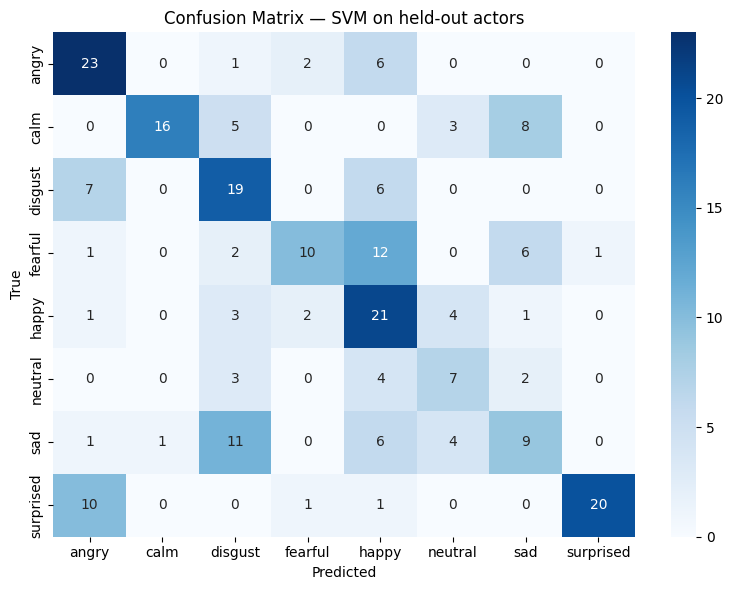

In [12]:
cm = confusion_matrix(y_test_e, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_name} on held-out actors")
plt.tight_layout()
plt.show()

## 9. Leave-one-actor-group-out cross-validation

One held-out test set is a single data point. To get a more honest accuracy estimate, we run 6 folds: actors are split into 6 gender-balanced groups of 4 (1M + 1F + 1M + 1F), each group taking a turn as the test set.

In [13]:
# 6 folds × 4 actors each, gender-balanced (2M + 2F per fold).
ACTOR_FOLDS = [
    {1, 2, 3, 4},
    {5, 6, 7, 8},
    {9, 10, 11, 12},
    {13, 14, 15, 16},
    {17, 18, 19, 20},
    {21, 22, 23, 24},
]

fold_accs = []
for i, fold_actors in enumerate(ACTOR_FOLDS, 1):
    test_m = np.isin(actors, list(fold_actors))
    train_m = ~test_m

    sc = StandardScaler().fit(X[train_m])
    Xtr, Xte = sc.transform(X[train_m]), sc.transform(X[test_m])
    ytr, yte = le.transform(y[train_m]), le.transform(y[test_m])

    # Use the same architecture as the chosen best model for fair CV.
    if best_name == "MLP":
        clf = MLPClassifier(
            hidden_layer_sizes=(512, 256),
            max_iter=400,
            early_stopping=True,
            n_iter_no_change=15,
            random_state=RNG,
        )
    else:
        clf = SVC(C=10.0, kernel="rbf", gamma="scale", random_state=RNG)

    clf.fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    fold_accs.append(acc)
    print(f"Fold {i} (actors {sorted(fold_actors)}): {acc:.4f}")

print(f"\nMean CV accuracy: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

Fold 1 (actors [1, 2, 3, 4]): 0.6542
Fold 2 (actors [5, 6, 7, 8]): 0.6417


Fold 3 (actors [9, 10, 11, 12]): 0.5083
Fold 4 (actors [13, 14, 15, 16]): 0.5292


Fold 5 (actors [17, 18, 19, 20]): 0.5250
Fold 6 (actors [21, 22, 23, 24]): 0.5458

Mean CV accuracy: 0.5674 ± 0.0581


## 10. Save the model bundle

We save the model, scaler, and label encoder together so prediction code only needs one file.

In [14]:
bundle = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "model_name": best_name,
    "feature_dim": X.shape[1],
}
joblib.dump(bundle, MODEL_PATH)
print(f"Saved bundle → {MODEL_PATH.resolve()} ({MODEL_PATH.stat().st_size / 1e6:.2f} MB)")

Saved bundle → /Users/kartik/voice-emotion-detection/emotion_model.pkl (2.85 MB)


## 11. Predict on a random sample

Sanity check: load the saved bundle, pick a random `.npy` from the test actors, and predict.

In [15]:
loaded = joblib.load(MODEL_PATH)
lm = loaded["model"]
ls = loaded["scaler"]
lle = loaded["label_encoder"]

test_records = [r for r in records if r[2] in TEST_ACTORS]
fpath, true_emotion, actor_id = random.choice(test_records)

vec = extract_features(np.load(fpath)).reshape(1, -1)
vec_s = ls.transform(vec)
pred_idx = lm.predict(vec_s)[0]
pred_emotion = lle.inverse_transform([pred_idx])[0]

if hasattr(lm, "predict_proba"):
    probs = lm.predict_proba(vec_s)[0]
    top = sorted(zip(lle.classes_, probs), key=lambda x: -x[1])
else:
    top = [(pred_emotion, 1.0)]

print(f"File:           {fpath.name}")
print(f"Actor:          {actor_id}")
print(f"True emotion:   {true_emotion}")
print(f"Predicted:      {pred_emotion}  {'✓' if pred_emotion == true_emotion else '✗'}")
print("\nTop probabilities:")
for emo, p in top[:5]:
    print(f"  {emo:10s} {p:.3f}")

File:           03-01-06-02-02-02-23.npy
Actor:          23
True emotion:   fearful
Predicted:      angry  ✗

Top probabilities:
  happy      0.347
  angry      0.306
  fearful    0.286
  surprised  0.026
  disgust    0.014
